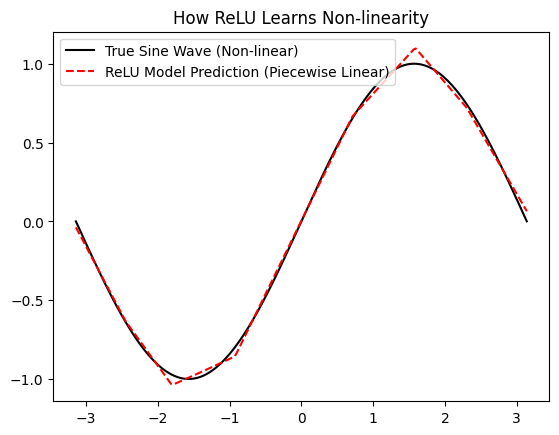

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 1. 의도적으로 비선형적인 데이터 생성 (Sine 곡선)
X = torch.linspace(-np.pi, np.pi, 200).view(-1, 1)
y = torch.sin(X)

# 2. 아주 얕고 뉴런이 적은 MLP 모델 정의 (꺾이는 지점을 눈으로 보기 위함)
model = nn.Sequential(
    nn.Linear(1, 10),  # 10개의 뉴런 = 최대 10번 꺾일 수 있음
    nn.ReLU(),
    nn.Linear(10, 1)
)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 3. 학습
for epoch in range(1000):
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, y)
    loss.backward()
    optimizer.step()

# 4. 시각화 (진짜 직선들이 이어져서 곡선을 만들었는지 확인)
predicted = model(X).detach().numpy()
plt.plot(X.numpy(), y.numpy(), label='True Sine Wave (Non-linear)', color='black')
plt.plot(X.numpy(), predicted, label='ReLU Model Prediction (Piecewise Linear)', color='red', linestyle='--')
plt.title("How ReLU Learns Non-linearity")
plt.legend()
plt.show()